Historical data shape: (6722, 22)
Currency metadata shape: (21, 3)

Historical data columns:
['Date', 'USD/EUR', 'USD/GBP', 'USD/JPY', 'USD/CHF', 'USD/CAD', 'USD/AUD', 'USD/SGD', 'USD/KRW', 'USD/CNY', 'USD/INR', 'USD/BRL', 'USD/ZAR', 'USD/RUB', 'USD/MXN', 'USD/IDR', 'USD/TRY', 'USD/VND', 'USD/LKR', 'USD/NGN ', 'USD/KES', 'USD/BDT']

Currency metadata:
      Country/Zone             Economy Type Conversion Name
0           Europe        Developed Economy         USD/EUR
1   United Kingdom        Developed Economy         USD/GBP
2            Japan        Developed Economy         USD/JPY
3      Switzerland        Developed Economy         USD/CHF
4           Canada        Developed Economy         USD/CAD
5        Australia        Developed Economy         USD/AUD
6        Singapore        Developed Economy         USD/SGD
7      South Korea        Developed Economy         USD/KRW
8            China  Emerging Market Economy         USD/CNY
9            India  Emerging Market Economy   

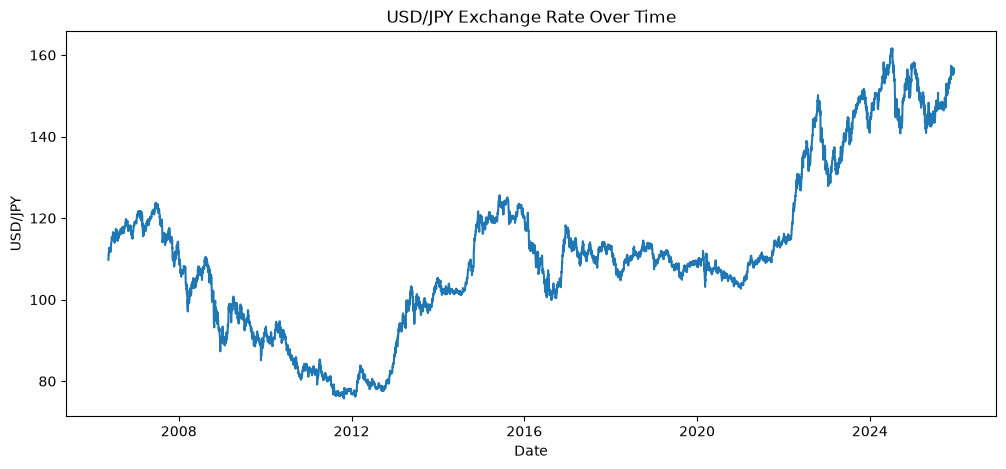

In [32]:
# 1. Import libraries

import pandas as pd
import matplotlib.pyplot as plt


# 2. Load datasets

historical_df = pd.read_csv("../data/raw/Historical Data.csv")
currency_df = pd.read_csv("../data/raw/Currencies and Country EconomyWise.csv")

# 3. Inspect the datasets

print("Historical data shape:", historical_df.shape)
print("Currency metadata shape:", currency_df.shape)

print("\nHistorical data columns:")
print(historical_df.columns.tolist())

print("\nCurrency metadata:")
print(currency_df)

# 4. Convert Date to datetime

historical_df["Date"] = pd.to_datetime(
    historical_df["Date"],
    format="%d-%m-%Y"
)

print("Earliest date:", historical_df["Date"].min())
print("Latest date:", historical_df["Date"].max())
print("Sorted:", historical_df["Date"].is_monotonic_increasing)

# 5. Analyze missing values

missing_values = historical_df.isnull().sum()

missing_percentage = (
    historical_df.isnull().sum() / len(historical_df)
) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

print(missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
))

# 6. Select USD/JPY as the target currency

target_currency = "USD/JPY"

usd_jpy_df = historical_df[
    ["Date", target_currency]
].copy()

# 7. Remove rows where the target is missing

usd_jpy_df = usd_jpy_df.dropna(
    subset=[target_currency]
).reset_index(drop=True)

print("Original rows:", len(historical_df))
print("Rows after removing missing USD/JPY:", len(usd_jpy_df))
print("Missing USD/JPY:", usd_jpy_df[target_currency].isnull().sum())

# 8. Visualize USD/JPY exchange rate

plt.figure(figsize=(12, 5))

plt.plot(
    usd_jpy_df["Date"],
    usd_jpy_df[target_currency]
)

plt.xlabel("Date")
plt.ylabel("USD/JPY")
plt.title("USD/JPY Exchange Rate Over Time")

plt.show()